# Morphology Pipeline Notebook
This notebook demonstrates the general procedure for transforming skeletons from image space to CCF space using the transforms generated during the registration pipeline.

In [1]:
import argparse
import logging
import os
import json
import shutil
from glob import glob
from pathlib import Path

import numpy as np
import ants
import zarr
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from allensdk.core.swc import Compartment, Morphology

from aind_morphology_utils import coordinate_mapping
from aind_morphology_utils.utils import read_swc

In [2]:
output_dir = "/results/754611"

## Load the tracing image

In [3]:
# This is the full resolution signal channel image that was used for tracing in horta
image_path = "s3://aind-open-data/exaSPIM_754611_2025-04-01_17-31-11_flatfield-correction_2025-04-17_19-32-12_fusion_2025-04-21_17-52-28/fused.zarr"

full_res_shape = zarr.open(image_path, 'r')['0'].shape[-3:]
print(full_res_shape) # ZYX

(20290, 38645, 63293)


## Load the CCFv3 10 micron average template

In [4]:
# The gold standard average template file
ccf_template_url  ="https://download.alleninstitute.org/informatics-archive/current-release/mouse_ccf/average_template/average_template_10.nrrd"
# download the template if it doesn't exist
ccf_template_path = Path("/results/ccf_template.nrrd")
# use curl to download the CCF template
if not ccf_template_path.exists():
    os.system(f"curl -o {ccf_template_path} {ccf_template_url}")

ccf_template = ants.image_read(str(ccf_template_path)).numpy()

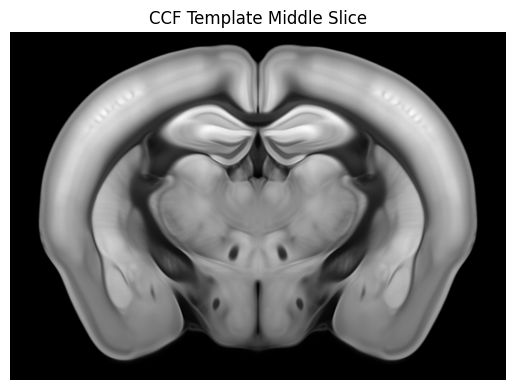

In [5]:
# plot the middle slice of the CCF template
ccf_template_slice = ccf_template[ccf_template.shape[0] // 2, ...]
plt.imshow(ccf_template_slice, cmap='gray')
plt.title("CCF Template Middle Slice")
plt.axis('off')
plt.show()

In [6]:
# From the above plot, we can see that the CCF template is oriented such that:
CCF_DIRECTIONS = {
    0: "Anterior_to_posterior", # Z
    1: "Superior_to_inferior", # Y 
    2: "Left_to_right", # X
}

# We define functions to re-orient the image to match the CCF template orientation
def get_adjustments(
    axes: dict, orientation: dict
):
    flips = []
    swaps = []
    for i in range(len(axes)):
        ax = axes[i]
        dim = ax["dimension"]
        direction = ax["direction"].lower()

        if orientation[dim].lower() == direction:
            # No change needed
            continue

        for idx, d in orientation.items():
            # Check if only a swap is needed
            if d.lower() == direction:
                swaps.append((dim, idx))
            # Check if flip is needed
            elif d.lower() == "_".join(direction.split("_")[::-1]):
                swaps.append((dim, idx))
                flips.append(idx)

    return swaps, flips


def adjust_array(arr: np.ndarray, swaps: list, flips: list) -> np.ndarray:
    if swaps:
        in_axis, out_axis = zip(*swaps)
        arr = np.moveaxis(arr, in_axis, out_axis)
    if flips:
        arr = np.flip(arr, axis=flips)
    return arr

## Read acqusition metadata and determine axis adjustments

In [7]:
acquisition = "/data/acquisition_corrected_754611.json"

with open(acquisition, 'r') as f:
    acquisition_data = json.load(f)
axes = acquisition_data.get('axes', None)
if axes is None:
    raise ValueError("Acquisition data does not contain 'axes' key.")

swaps, flips = get_adjustments(axes, CCF_DIRECTIONS)
print(f"Swaps: {swaps}, Flips: {flips}")

Swaps: [(2, 0), (1, 2), (0, 1)], Flips: [2, 1]


## Load all SWC files and define functions for scaling and reorientation

In [8]:
swc_dir = "/data/754611-cells-raw/754611"

all_swcs = list(sorted(glob(os.path.join(swc_dir, '**', '*.swc'), recursive=True)))
print(f"Found {len(all_swcs)} SWC files.")

Found 6 SWC files.


In [9]:
swc_scale = [1, 0.748, 0.748]  # ZYX, voxel size of horta image

In [10]:
def scale_morph(morph, scale):
    new_compartments = []
    for compartment in morph.compartment_list:
        c = Compartment(**compartment)
        c['z'] = compartment['z'] * scale[0]
        c['y'] = compartment['y'] * scale[1]
        c['x'] = compartment['x'] * scale[2]
        new_compartments.append(c)
    return Morphology(new_compartments)


def orient_morph(morph: Morphology, swaps: list, flips: list, shape: tuple = None) -> Morphology:
    
    coords = np.array([[c['z'], c['y'], c['x']] for c in morph.compartment_list])

    # Apply swaps using numpy.moveaxis logic
    if swaps:
        in_axis, out_axis = zip(*swaps)
        source = list(in_axis)
        destination = list(out_axis)
        order = [n for n in range(coords.shape[1]) if n not in source]
        for dest, src in sorted(zip(destination, source)):
            order.insert(dest, src)
        coords = coords[:, order]
        # Also permute shape if provided
        if shape is not None:
            shape = tuple(shape[i] for i in order)

    # Apply flips
    if flips and shape is not None:
        for axis in flips:
            coords[:, axis] = shape[axis] - coords[:, axis]

    # Create a new Morphology object with adjusted coordinates
    new_compartments = []
    for i, c in enumerate(morph.compartment_list):
        new_compartment = Compartment(**c)
        new_compartment['x'] = coords[i, 2]  
        new_compartment['y'] = coords[i, 1]  
        new_compartment['z'] = coords[i, 0]  
        new_compartments.append(new_compartment)
    adjusted_morph = Morphology(new_compartments)
    return adjusted_morph

In [11]:
def plot_orientation(example_swc, swc_scale, swaps, flips, full_res_shape):
    # Take the first SWC file as an example
    print(f"Visualizing reorientation for: {example_swc}")

    # Read the original morphology
    original_morph = read_swc(example_swc, add_offset=True)

    # Scale the coordinates to voxel space
    voxel_scaling = [1 / s for s in swc_scale]
    voxel_morph = scale_morph(original_morph, swc_scale)

    # Adjust orientation
    adjusted_morph = orient_morph(
        voxel_morph, swaps, flips, shape=full_res_shape
    )

    # Plotting
    fig = plt.figure(figsize=(12, 6))

    # Before reorientation
    ax1 = fig.add_subplot(121, projection='3d')
    for compartment in voxel_morph.compartment_list:
        if compartment['parent'] != -1:
            parent = voxel_morph.compartment_list[compartment['parent'] - 1]
            ax1.plot([compartment['x'], parent['x']], [compartment['y'], parent['y']], [compartment['z'], parent['z']], 'b')
    ax1.set_title('Before Reorientation')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')

    # After reorientation
    ax2 = fig.add_subplot(122, projection='3d')
    for compartment in adjusted_morph.compartment_list:
        if compartment['parent'] != -1:
            parent = adjusted_morph.compartment_list[compartment['parent'] - 1]
            ax2.plot([compartment['x'], parent['x']], [compartment['y'], parent['y']], [compartment['z'], parent['z']], 'r')
    ax2.set_title('After Reorientation')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')

    plt.tight_layout()
    plt.show()

Visualizing reorientation for: /data/754611-cells-raw/754611/N007-754611/N007-754611-dendrite-HS.swc


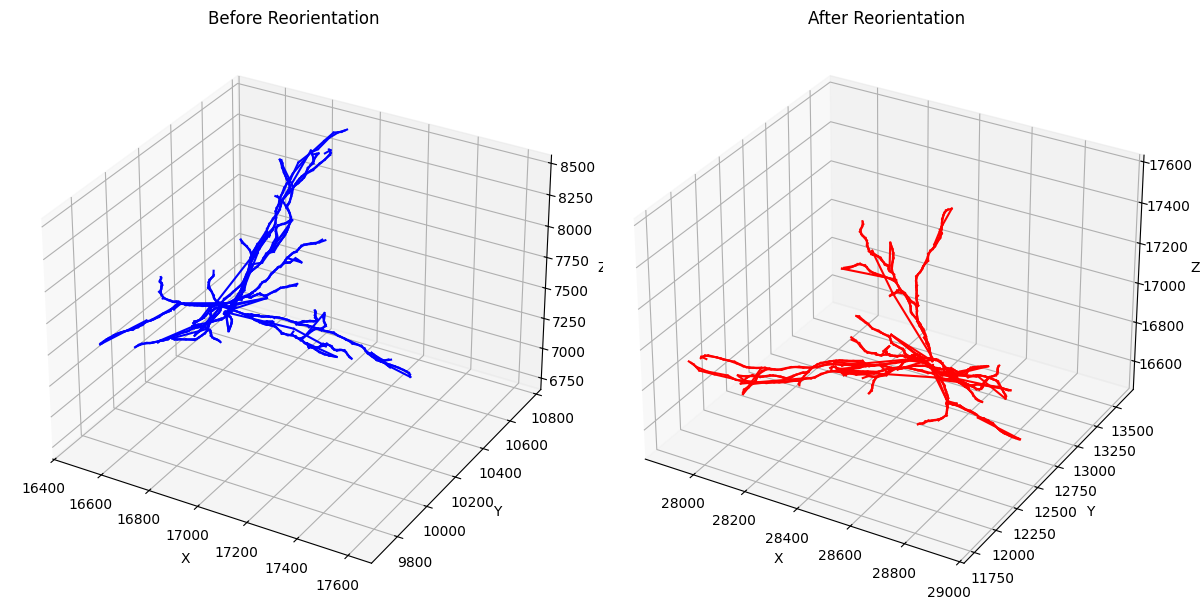

In [12]:
plot_orientation(all_swcs[1], swc_scale, swaps, flips, full_res_shape)

In [13]:
# Convert all swcs to voxel coordinates and adjust orientation to CCF directions
def scale_and_orient_swcs(all_swcs, swc_scale, swaps, flips, full_res_shape):
    all_morphs = []
    voxel_scaling = [1 / s for s in swc_scale]
    for swc_file in all_swcs:
        print(f"Processing SWC file: {swc_file}")
        morph = read_swc(swc_file, add_offset=True)
        # Convert to voxel coordinates
        morph = scale_morph(morph, voxel_scaling)
        # Adjust orientation
        morph = orient_morph(morph, swaps, flips, shape=full_res_shape)
        all_morphs.append(morph)

    return all_morphs

all_morphs = scale_and_orient_swcs(all_swcs, swc_scale, swaps, flips, full_res_shape)
print(all_morphs[0].compartment_list[0])

Processing SWC file: /data/754611-cells-raw/754611/N007-754611/N007-754611-axon-HS.swc
Processing SWC file: /data/754611-cells-raw/754611/N007-754611/N007-754611-dendrite-HS.swc
Processing SWC file: /data/754611-cells-raw/754611/N009-754611/N009-754611-axon-DS.swc
Processing SWC file: /data/754611-cells-raw/754611/N009-754611/N009-754611-dendrite-DS.swc
Processing SWC file: /data/754611-cells-raw/754611/N016-754611/N016-754611-axon-BP.swc
Processing SWC file: /data/754611-cells-raw/754611/N016-754611/N016-754611-dendrite-BP.swc
{'id': 0, 'type': 0, 'x': 20666.39037433155, 'y': 12609.0, 'z': 30118.98395721925, 'radius': 1.0, 'parent': -1, 'tree_id': 0, 'children': [1]}


## Specify scaling parameters used during registration

In [14]:
# Constant values used for resampling image prior to aligment
# We must also reorient the voxel size, etc to match the adjusted image, or the resampling will be incorrect due to anisotropy
expansion_adjusted_voxel_size_lvl_5 = adjust_array(np.asarray([13.5, 10.1, 10.1]).reshape(1, 1, -1), swaps, flips).squeeze().tolist()
expansion_adjusted_voxel_size_lvl_0 = [s / 2**5 for s in expansion_adjusted_voxel_size_lvl_5]
print(f"Expansion adjusted voxel size at level 5: {expansion_adjusted_voxel_size_lvl_5}")
print(f"Expansion adjusted voxel size at level 0: {expansion_adjusted_voxel_size_lvl_0}")

# Don't need to reorient since it is isotropic
transform_res = [10.0, 10.0, 10.0]  # ZYX

# We need to scale the full resolution (corrected for expansion factor) morphologies to the transform resolution
scale_factors = [expansion_adjusted_voxel_size_lvl_0[i] / transform_res[i] for i in range(3)]
print(f"Scale factors for full resolution morphologies: {scale_factors}")

Expansion adjusted voxel size at level 5: [13.5, 10.1, 10.1]
Expansion adjusted voxel size at level 0: [0.421875, 0.315625, 0.315625]
Scale factors for full resolution morphologies: [0.0421875, 0.0315625, 0.0315625]


## Resample morphologies to transform resolution

In [15]:
# Scale the morphologies to the transform resolution
downscaled_morphs = []
for morph in all_morphs:
    downsampled_morph = scale_morph(morph, scale_factors)
    downscaled_morphs.append(downsampled_morph)
print(downscaled_morphs[0].compartment_list[0])

{'id': 0, 'type': 0, 'x': 652.2829461898395, 'y': 397.9715625, 'z': 1270.6446356951872, 'radius': 1.0, 'parent': -1, 'tree_id': 0, 'children': [1]}


## Load the CCF channel Zarr image, reorient and resample to transform resolution

In [16]:
binned_image_path = "s3://aind-open-data/exaSPIM_754611_2025-04-01_17-31-11_flatfield-correction_2025-05-22_17-06-16_fusion_2025-05-22_17-40-43/fused.zarr"

binned_image = zarr.open(binned_image_path, 'r')['2'][:].squeeze()
print(binned_image.shape)  # ZYX

(634, 1207, 1978)


In [17]:
binned_image_oriented = adjust_array(binned_image, swaps, flips)
print(binned_image_oriented.shape)  # ZYX

(1978, 634, 1207)


In [18]:
binned_image_oriented_ants = ants.from_numpy(binned_image_oriented)
binned_image_oriented_ants.set_spacing(expansion_adjusted_voxel_size_lvl_5)

In [19]:
# resample the image to the transform resolution
binned_image_resampled = ants.resample_image(
    binned_image_oriented_ants,
    transform_res,
    interp_type=0
).numpy().astype(np.uint16)
print(binned_image_resampled.shape)

(2670, 640, 1219)


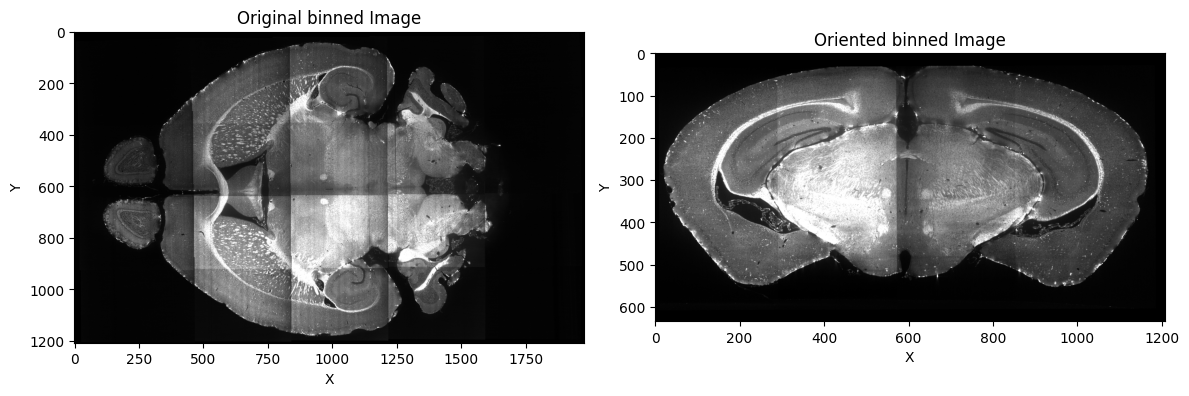

In [20]:
# Plot a slice of the original and oriented binned images to compare
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(binned_image[binned_image.shape[0] // 2, :, :], cmap='gray', vmin=0, vmax=1000)
axes[0].set_title('Original binned Image')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

axes[1].imshow(binned_image_oriented[binned_image_oriented.shape[0] // 2, :, :], cmap='gray', vmin=0, vmax=1000)
axes[1].set_title('Oriented binned Image')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

plt.tight_layout()
plt.show()

In [21]:
# Incorrect resampling
resampled_image_asset = ants.image_read("/data/reg_754611_to_ccf_25um_v1.2/754611_10um_resampled_zarr_img.nii.gz")
resampled_image_asset = resampled_image_asset.numpy().astype(np.uint16)
print(resampled_image_asset.shape)

(2003, 642, 1629)


In [22]:
def plot_orthogonal_views(image, morphology, center_point_px, title=""):
    """
    Visualizes a morphology overlaid on three orthogonal slices of an image.

    Args:
        image (np.ndarray): The 3D image data, expected in (Z, Y, X) order.
        morphology: The morphology object with compartments in pixel coordinates for the given image.
        center_point_px (tuple): The (x, y, z) center point for slicing, in image pixel coordinates.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Get slice indices from center point. Image is ZYX, center_point is XYZ.
    slice_z, slice_y, slice_x = int(center_point_px[2]), int(center_point_px[1]), int(center_point_px[0])

    vmin, vmax = 0, 1000

    # Ensure slices are within image bounds
    slice_x = max(0, min(slice_x, image.shape[2] - 1))
    slice_y = max(0, min(slice_y, image.shape[1] - 1))
    slice_z = max(0, min(slice_z, image.shape[0] - 1))

    # --- XY View (slice along Z axis) ---
    axes[0].imshow(image[slice_z, :, :], cmap='gray', vmin=vmin, vmax=vmax)
    axes[0].set_title(f'XY View at Z={slice_z}')
    axes[0].set_xlabel('X pixel')
    axes[0].set_ylabel('Y pixel')

    # --- YZ View (slice along X axis) ---
    axes[1].imshow(image[:, :, slice_x], cmap='gray', vmin=vmin, vmax=vmax)
    axes[1].set_title(f'YZ View at X={slice_x}')
    axes[1].set_xlabel('Y pixel')
    axes[1].set_ylabel('Z pixel')

    # --- XZ View (slice along Y axis) ---
    axes[2].imshow(image[:, slice_y, :], cmap='gray', vmin=vmin, vmax=vmax)
    axes[2].set_title(f'XZ View at Y={slice_y}')
    axes[2].set_xlabel('X pixel')
    axes[2].set_ylabel('Z pixel')

    # Plot morphology on all three views
    for compartment in morphology.compartment_list:
        if compartment['parent'] != -1:
            parent = morphology.compartment_list[compartment['parent'] - 1]
            
            x1, y1, z1 = compartment['x'], compartment['y'], compartment['z']
            x2, y2, z2 = parent['x'], parent['y'], parent['z']

            # Plot on XY view
            axes[0].plot([x1, x2], [y1, y2], 'r-', linewidth=0.5)
            # Plot on YZ view
            axes[1].plot([y1, y2], [z1, z2], 'r-', linewidth=0.5)
            # Plot on XZ view
            axes[2].plot([x1, x2], [z1, z2], 'r-', linewidth=0.5)

    # Highlight the center point
    axes[0].scatter(center_point_px[0], center_point_px[1], c='yellow', marker='*')
    axes[1].scatter(center_point_px[1], center_point_px[2], c='yellow', marker='*')
    axes[2].scatter(center_point_px[0], center_point_px[2], c='yellow', marker='*')

    plt.tight_layout()
    plt.title(title)
    plt.show()

/data/754611-cells-raw/754611/N007-754611/N007-754611-dendrite-HS.swc


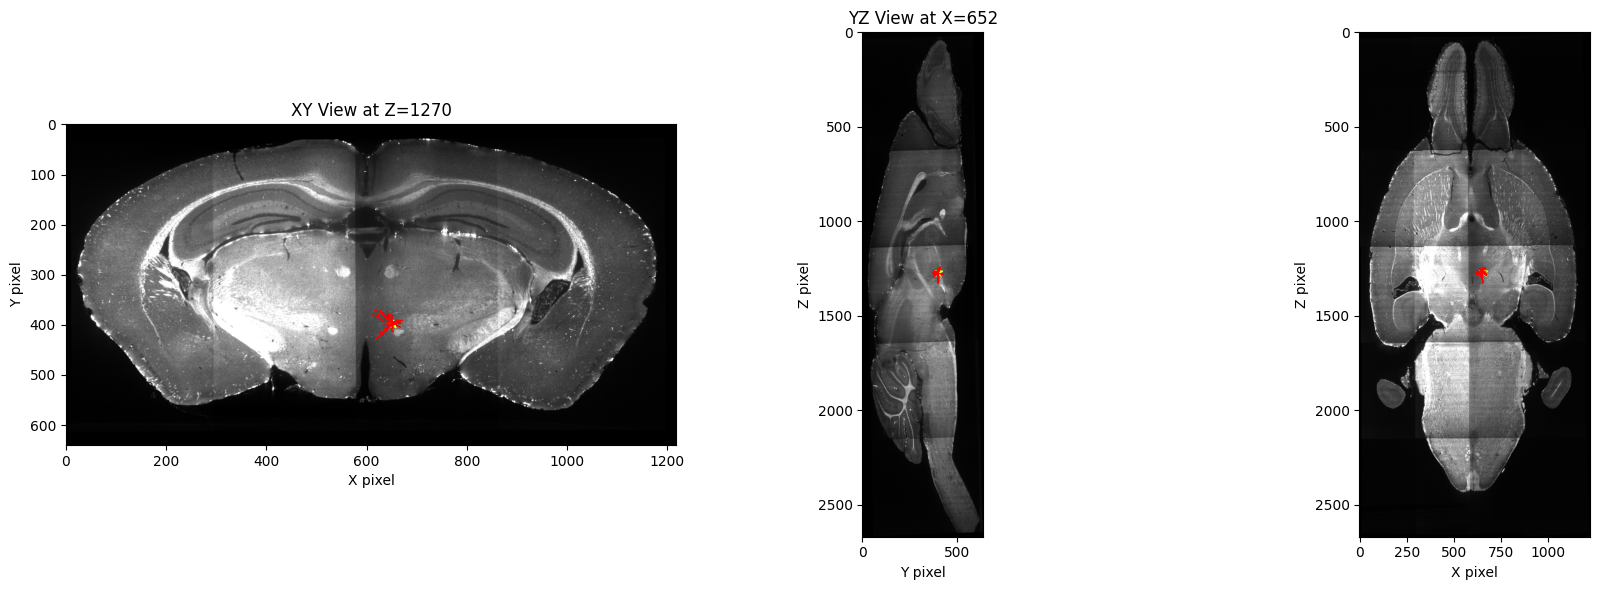

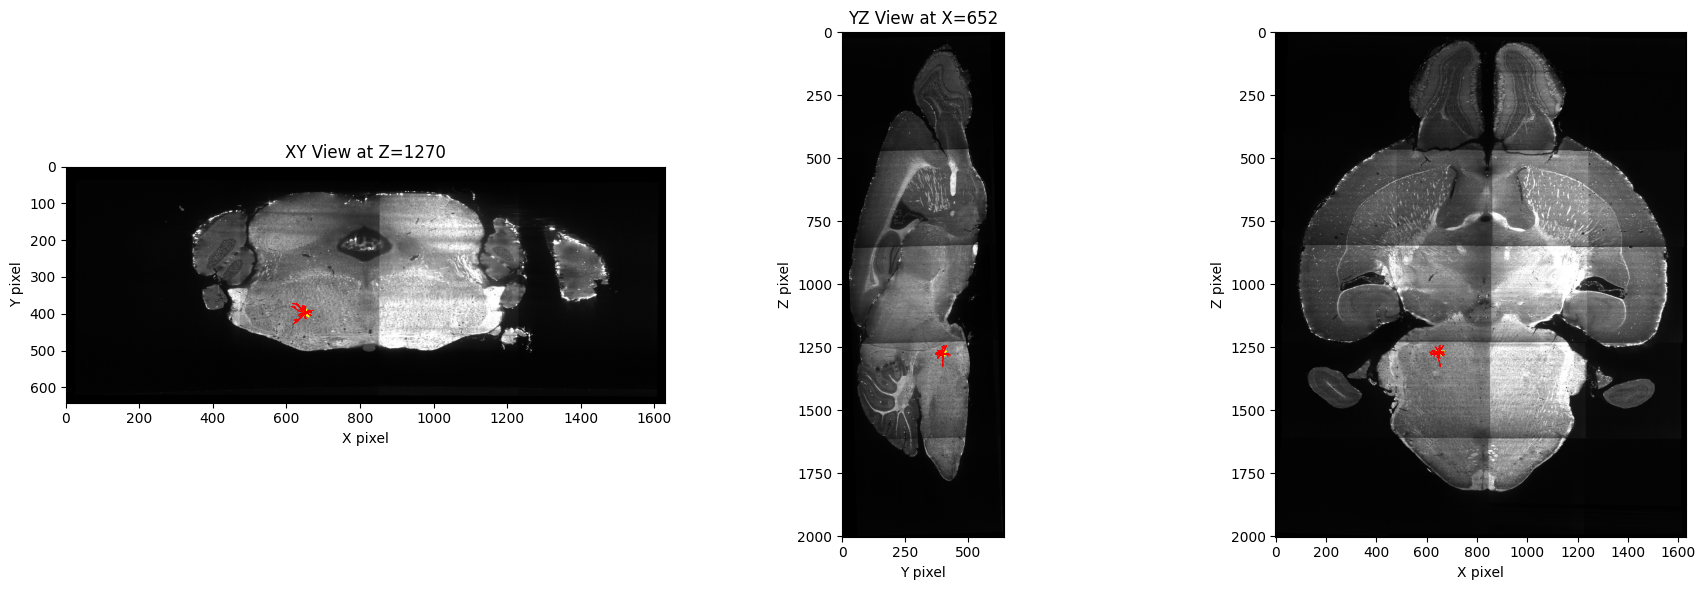

In [23]:
print(all_swcs[1])
example_morph = downscaled_morphs[1]

# Get the soma position as the center point
soma = example_morph.compartment_list[0]
center_point = (soma['x'], soma['y'], soma['z'])

# Compare 
plot_orthogonal_views(binned_image_resampled, example_morph, center_point)
plot_orthogonal_views(resampled_image_asset, example_morph, center_point)

## Set Up Transforms
Retrieve the voxel size from the image and set up the coordinate transforms.

In [24]:
def read_transforms(affine_path, warp_path):
    affinetx = ants.read_transform(affine_path).invert()
    warptx = ants.transform_from_displacement_field(ants.image_read(warp_path))
    return affinetx, warptx

In [25]:
image_to_exaspim_affine, image_to_exaspim_warp = read_transforms(
    affine_path="/data/reg_754611_to_ccf_25um_v1.2/754611_to_exaSPIM_SyN_0GenericAffine.mat",
    warp_path = "/data/reg_754611_to_ccf_25um_v1.2/754611_to_exaSPIM_SyN_1Warp.nii.gz"
)

exaspim_to_ccf_affine, exaspim_to_ccf_warp = read_transforms(
    affine_path="/root/capsule/data/reg_exaspim_template_to_ccf_25um_v1.2/0GenericAffine.mat",
    warp_path="/root/capsule/data/reg_exaspim_template_to_ccf_25um_v1.2/1Warp.nii.gz"
)

In [26]:
aligned_dir = os.path.join(output_dir, 'aligned')
print(f"Creating aligned directory: {aligned_dir}")
os.makedirs(aligned_dir, exist_ok=True)

Creating aligned directory: /results/754611/aligned


## Transform Each Morphology

In [27]:
aligned_morphs = []

for i, morph in enumerate(downscaled_morphs):
    new_compartments = []
    for node in morph.compartment_list:
        c = Compartment(**node)
        
        pt = np.array([node["z"], node["y"], node["x"]])

        pt = image_to_exaspim_affine.apply_to_point(pt)
        pt = image_to_exaspim_warp.apply_to_point(pt)

        pt = exaspim_to_ccf_affine.apply_to_point(pt)
        pt = exaspim_to_ccf_warp.apply_to_point(pt)

        c["z"] = pt[0] * transform_res[0]  # Convert to CCF space
        c["y"] = pt[1] * transform_res[1]
        c["x"] = pt[2] * transform_res[2]
        
        new_compartments.append(c)
        
    aligned_morph = Morphology(new_compartments)
    aligned_morphs.append(aligned_morph)

    # Save transformed SWC
    transformed_path = os.path.join(aligned_dir, f"aligned_{i:04d}.swc")
    os.makedirs(os.path.dirname(transformed_path), exist_ok=True)
    aligned_morph.save(transformed_path)